# 3.4 找到位置後，實際取回的是什麼？


書目幫你找到一本書，真正讀的是書的內容。注意力也把匹配線索與取回內容分開：每個候選位置除了 key，還準備 **value**，縮寫 V，表示要按比例帶回的數字。

本節需求為 `[1,0]`，兩個 key 是 `[1,0]` 與 `[0,1]`，匹配分數是 1、0，softmax 後比例約 0.731、0.269。兩個位置的 value 則各有三格：`[10,20,30]` 與 `[-1,-2,-3]`。key 兩格足以做本例匹配，不表示取回內容也只能兩格。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

In [2]:
import torch

q = torch.tensor([[1.0, 0.0]])
k = torch.tensor([[1.0, 0.0], [0.0, 1.0]])
v = torch.tensor([[10.0, 20.0, 30.0], [-1.0, -2.0, -3.0]])
weights = (q @ k.T).softmax(dim=-1)
output = weights @ v
print(weights)
print(output, output.shape)

tensor([[0.7311, 0.2689]])
tensor([[ 7.0416, 14.0833, 21.1249]]) torch.Size([1, 3])


第一格輸出為 `0.731×10+0.269×(-1)≈7.042`；其餘兩格為 14.083、21.125。每個查詢取回一張三格卡，所以輸出形狀 `[1,3]`，由 V 的寬度決定。


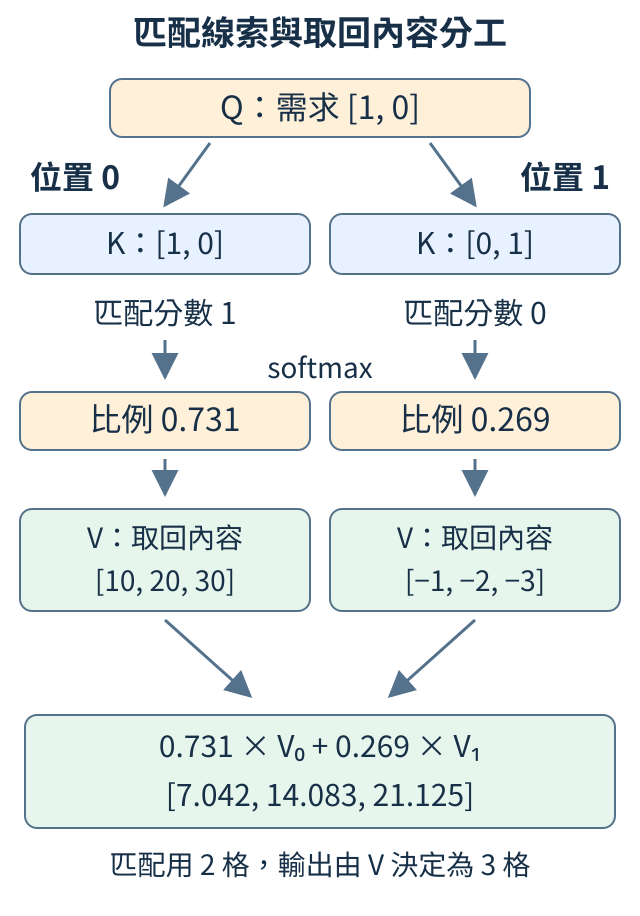

In [3]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/rewrite-03-qkv-flow.svg")))

圖中兩位置始終按相同順序排列。左比例乘左 V，右比例乘右 V；若調換 V 的列卻不調換對應 key，會把找到第一份的比例套到第二份內容，算出另一個答案。

整條運算可寫 `softmax(QKᵀ)V`：先匹配，再分配讀取比例，最後混合內容。Q、K、V 都是數字表示。實際自注意力先把各位置的輸入表示排成一張表，稱為 X；每排是該位置目前的一串數字。同一張 X 分別通過三套 Linear，為各位置產生 Q、K、V，三套權重都可訓練。本節為看清三者分工，直接填入一個查詢與兩個候選的數字，沒有執行產生它們的三套 Linear 或訓練。

練習只將第一個 V 改成 `[20,40,60]`，Q/K 不動，比例保持相同，輸出變約 `[14.352,28.704,43.057]`。這是最直接的角色檢查：定位線索沒改，帶回內容改了。

混合多張卡後只留一張，通常不能由結果完整還原每張來源。注意力是在建立此刻有用的表示，後面還會另留一條原表示的路線。

<details>
<summary>補充與重做</summary>

Tq 個查詢、Tk 個候選、每份 V 有 Dv 格，則權重 `[Tq,Tk]` 乘 V `[Tk,Dv]` 得 `[Tq,Dv]`。本節仍用未縮放的透明算例；完整縮放規則在下一節。

</details>
